# Pre-processing: GHS-SMOD urban / rural raster

Stream the JRC Global Human Settlement Layer **SMOD** product, clip it to an AOI, and reclassify it into a single Urban / Rural / nodata raster. Mirrors the AOI used in `worldpop_pre_processing.ipynb` so the two outputs share a footprint.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

from d_health import GHSSmodConfig, get_smod_data

## 2. Configure the run

Same Paramaribo bounding box as `worldpop_pre_processing.ipynb`, so the SMOD output shares the AOI footprint with the population raster. `cfg` defaults to the 2025 epoch, R2023A release, 30 arc-second (~1 km) global product in EPSG:4326 — i.e. the file `GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.tif`.

In [2]:
output_dir = Path("./outputs")

# Paramaribo bounding box in EPSG:4326 (xmin, ymin, xmax, ymax) — same as the population notebook.
paramaribo_bounds = (-55.27, 5.78, -55.10, 5.93)

cfg = GHSSmodConfig()  # E2025, R2023A, V2-0, 4326, 30ss
cfg

GHSSmodConfig(epoch=2025, release='R2023A', version='V2-0', crs_code='4326', resolution='30ss')

## 3. Fetch and reclassify

`get_smod_data` streams the global SMOD ZIP from the JRC open-data server into a temp directory, extracts the GeoTIFF, masks it to `paramaribo_bounds`, and reclassifies in memory. The ZIP and the global-extent TIF are deleted before the call returns — only the reclassified raster lands in `output_dir`:

| Output | Meaning | Source SMOD classes |
|---|---|---|
| `1` | Urban  | 30, 23, 22, 21 |
| `2` | Rural  | 13, 12, 11 |
| `0` | nodata | water (10) + pixels outside the AOI |

Only the reclassified raster is written into `output_dir / "smod"`.

In [3]:
raster_path = get_smod_data(
    output_dir / "smod",
    clip=paramaribo_bounds,
    cfg=cfg,
)
raster_path

d_health.get_smod_data | INFO | GHS-SMOD R2023A E2025 (4326, 30ss) — clip=yes
d_health.get_smod_data | INFO | Downloading https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_SMOD_GLOBE_R2023A/GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss/V2-0/GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.zip
d_health.get_smod_data | INFO | Saved GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.zip (34.0 MB)
d_health.get_smod_data | INFO | Extracted GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0.tif
d_health.get_smod_data | INFO | Wrote GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0_urban_rural.tif (19 × 21, urban=193 rural=128 nodata=78, 0.00 MB)


WindowsPath('outputs/smod/GHS_SMOD_E2025_GLOBE_R2023A_4326_30ss_V2_0_urban_rural.tif')

## 4. Inspect the output

Sanity-check: single band, uint8, only values `{0, 1, 2}`, nodata = 0.

In [4]:
with rasterio.open(raster_path) as src:
    assert src.count == 1, src.count
    print("CRS:    ", src.crs)
    print("Shape:  ", src.shape)
    print("Dtype:  ", src.dtypes[0])
    print("NoData: ", src.nodata)
    print("Bands:  ", src.descriptions)
    arr = src.read(1)

unique, counts = np.unique(arr, return_counts=True)
labels = {0: "nodata", 1: "urban", 2: "rural"}
print("\nPixel counts:")
for value, count in zip(unique, counts):
    pct = 100 * count / arr.size
    print(f"  {value} ({labels.get(int(value), '?')}): {count:>8,} ({pct:5.1f}%)")

assert set(unique.tolist()) <= {0, 1, 2}, unique

CRS:     EPSG:4326
Shape:   (19, 21)
Dtype:   uint8
NoData:  0.0
Bands:   ('urban_rural',)

Pixel counts:
  0 (nodata):       78 ( 19.5%)
  1 (urban):      193 ( 48.4%)
  2 (rural):      128 ( 32.1%)


## 5. Visualise

Discrete colormap — light grey for nodata, red for urban, green for rural.

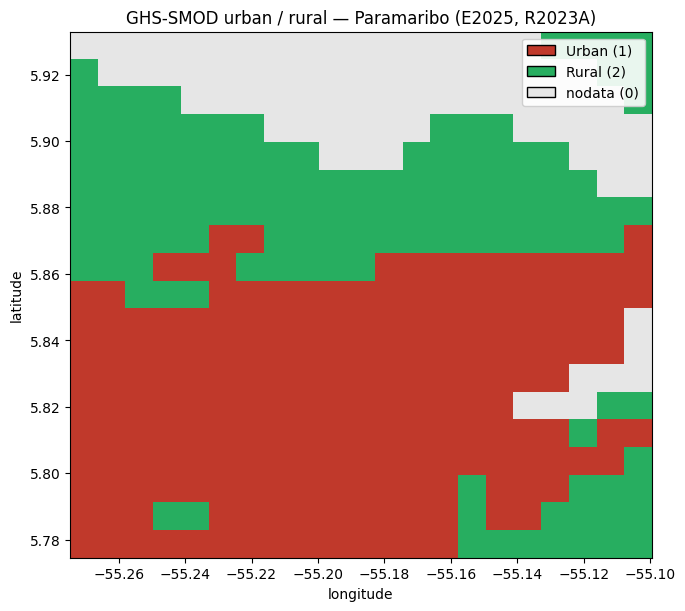

In [5]:
colors = {0: "#e6e6e6", 1: "#c0392b", 2: "#27ae60"}
cmap = ListedColormap([colors[0], colors[1], colors[2]])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

with rasterio.open(raster_path) as src:
    bounds = src.bounds  # (left, bottom, right, top)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.imshow(
    arr, cmap=cmap, norm=norm,
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
)
ax.set_title(f"GHS-SMOD urban / rural — Paramaribo (E{cfg.epoch}, {cfg.release})")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

legend = [
    Patch(facecolor=colors[1], edgecolor="black", label="Urban (1)"),
    Patch(facecolor=colors[2], edgecolor="black", label="Rural (2)"),
    Patch(facecolor=colors[0], edgecolor="black", label="nodata (0)"),
]
ax.legend(handles=legend, loc="upper right", framealpha=0.9)
plt.show()